#ECB Rates and Bank Lending, 2019–2025

How did euro area bank lending rates and volumes react to the ECB policy rate cycle: negative
rates until mid-2022, the fastest hiking cycle in the history of the euro (July 2022 –
September 2023) and the first cuts in 2024?

Monthly euro area series from the ECB Data Portal (MFI interest rate statistics and loan
volumes, HICP inflation, ECB policy rates) and the Deposit Facility Rate from FRED.
Volumes are in EUR millions, rates in % per year.

## Setup

In [1]:
suppressPackageStartupMessages({
  library(readr)      # read_csv / write_csv
  library(dplyr)      # data manipulation (filter, mutate, joins, summarise)
  library(tidyr)      # fill() and pivot_longer()
  library(purrr)      # map / reduce over lists of series
  library(lubridate)  # floor_date / ceiling_date to work with months
  library(ggplot2)    # charts
  library(scales)     # axis label formats
})

In [2]:
# Size of the charts shown in the notebook
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 110)

In [3]:
DATA_DIR <- "data"                 # input CSV files (public ECB and FRED data)
OUT_DIR  <- "output"               # tables and charts written by the script
START    <- as.Date("2019-01-01")  # first month of the analysis

# Lending products: for each one, the file with its interest rate and the file with its
# volume (ECB Data Portal downloads). `key` is the short name used in the rest of the code.
#   mortgage*     new loans for house purchase, overall and by initial rate fixation period
#   hh_stock      outstanding household loans (a stock, not new business)
#   hh_revolving  revolving loans and overdrafts to households
#   hh_credit     consumer credit to households
#   corp_*        new loans to non-financial corporations by loan size
PRODUCTS <- tribble(
  ~key,             ~rate_file,                    ~volume_file,
  "mortgage",       "IR_mortgage.csv",             "Mortgage_Vol.csv",
  "mortgage_1_5",   "IR_mortgage_1-5.csv",         "Vol_mortgage_1-5.csv",
  "mortgage_5_10",  "IR_mortgage_5-10.csv",        "Vol_mortgage_5-10.csv",
  "mortgage_10",    "IR_mortgage_10+.csv",         "Vol_mortgage_10+.csv",
  "hh_stock",       "IR_Overall_HH.csv",           "Outstanding_HH_Loans.csv",
  "hh_revolving",   "IR_Household_Revolving.csv",  "Vol_Household_Revolving.csv",
  "hh_credit",      "IR_Household_Credit.csv",     "Vol_Household_Credit.csv",
  "corp_u250",      "IR_Corp_u250.csv",            "Vol_Corp_u250.csv",
  "corp_250_1m",    "IR_Corp_250_to_1M.csv",       "Vol_Corp_250_to_1M.csv",
  "corp_o1m",       "IR_Corp_o1M.csv",             "Vol_Corp_o1M.csv"
)

## 1. Loading the data

Every ECB file has the columns `DATE`, `TIME PERIOD` and the value. Series are always
aligned **on the calendar month**, never by row position, so a missing or extra month in one
file cannot shift the others. Policy rates are published only on the dates they change, so
each rate is carried forward until its next change.

In [4]:
# read_ecb_monthly(file, name)
# Reads one monthly ECB Data Portal CSV and returns a two-column table: `month` (first day
# of the month, used as the key to align series) and the value, renamed to `name`. The value
# is always the last column of the file. Months before a series starts have no value, which
# readr reports as a parsing issue: those rows simply become NA.
read_ecb_monthly <- function(file, name) {
  df <- suppressWarnings(read_csv(file.path(DATA_DIR, file), show_col_types = FALSE))
  tibble(month = floor_date(as.Date(df$DATE), "month"),   # e.g. 2023-03-31 -> 2023-03-01
         !!name := as.numeric(df[[ncol(df)]])) %>%        # value column, named after `name`
    filter(month >= START)
}

# read_policy_rates()
# Returns one row per calendar day with the MRO, MLF and DFR in force on that day.
# The source files list only the dates on which a rate changed, so the three step series are
# merged on the date, placed on a complete daily calendar, and each rate is carried forward
# (fill "down") until its next change.
read_policy_rates <- function() {
  # One step series: the change dates and the new level of the rate
  steps <- function(file, date_col, name) {
    df <- read_csv(file.path(DATA_DIR, file), show_col_types = FALSE)
    tibble(date = as.Date(df[[date_col]]), !!name := as.numeric(df[[ncol(df)]]))
  }
  rates <- list(steps("MRO.csv", "DATE", "MRO"),               # ECB Data Portal
                steps("MLF.csv", "DATE", "MLF"),               # ECB Data Portal
                steps("DFR.csv", "observation_date", "DFR")) %>% # FRED, daily
    reduce(full_join, by = "date")                             # one table, one row per date
  tibble(date = seq(min(rates$date), max(rates$date), by = "day")) %>%  # every calendar day
    left_join(rates, by = "date") %>%
    arrange(date) %>%
    fill(MRO, MLF, DFR, .direction = "down") %>%   # a rate stays in force until it changes
    filter(date >= START)
}

daily_rates <- read_policy_rates()
hicp <- read_ecb_monthly("HICP.csv", "HICP")   # annual HICP inflation, %

# One table per lending product with its monthly rate and volume, aligned on the month.
# Only months where both the rate and the volume are available are kept.
products <- pmap(PRODUCTS, function(key, rate_file, volume_file) {
  full_join(read_ecb_monthly(rate_file, "rate"), read_ecb_monthly(volume_file, "volume"),
            by = "month") %>%
    filter(!is.na(rate), !is.na(volume))
}) %>% set_names(PRODUCTS$key)   # access as products$mortgage, products$corp_o1m, ...

# Check: first and last month and number of months of each lending series
imap_dfr(products, ~ tibble(series = .y, first = min(.x$month), last = max(.x$month),
                           months = nrow(.x)))

series,first,last,months
<chr>,<date>,<date>,<int>
mortgage,2019-01-01,2025-01-01,73
mortgage_1_5,2019-01-01,2025-01-01,73
mortgage_5_10,2019-01-01,2025-01-01,73
mortgage_10,2019-01-01,2025-01-01,73
hh_stock,2019-01-01,2025-01-01,73
hh_revolving,2019-01-01,2025-01-01,73
hh_credit,2019-01-01,2025-01-01,73
corp_u250,2019-01-01,2025-01-01,73
corp_250_1m,2019-01-01,2025-01-01,73


## 2. Volume-weighted lending rates by sector

To compare sectors with the policy rate, the rates of the different loan types are combined
into one rate per sector, weighting each by its volume: sum(rate × volume) / sum(volume).
- **Households (consumption)**: consumer credit and revolving loans
- **Corporations**: loans up to EUR 250k, EUR 250k–1M and over EUR 1M

In [5]:
# weighted_rate(keys)
# Combines the products listed in `keys` into one monthly rate, weighting each product's rate
# by its volume in that month: sum(rate x volume) / sum(volume). A month is kept only if every
# product has data, so the mix of products does not change from one month to the next.
weighted_rate <- function(keys) {
  map_dfr(keys, ~ products[[.x]]) %>%        # stack the products one under the other
    group_by(month) %>%
    filter(n() == length(keys)) %>%          # months where every component exists
    summarise(rate = sum(rate * volume) / sum(volume), .groups = "drop")
}

# Monthly MRO: the rate in force on the last day of each month (the last daily observation)
mro_monthly <- daily_rates %>%
  mutate(month = floor_date(date, "month")) %>%
  group_by(month) %>%
  slice_max(date, n = 1) %>%   # last day of the month
  ungroup() %>%
  select(month, MRO)

# All sector series in one long table (month, rate, series), ready for the chart.
# The period is cut at the last month of the mortgage series, so all lines end together.
sector_rates <- list(
  MRO         = mro_monthly %>% rename(rate = MRO),
  Mortgages   = products$mortgage %>% select(month, rate),                 # ECB overall rate
  Households  = weighted_rate(c("hh_credit", "hh_revolving")),             # consumption
  Corporations = weighted_rate(c("corp_u250", "corp_250_1m", "corp_o1m"))  # all loan sizes
) %>%
  imap_dfr(~ mutate(.x, series = .y)) %>%   # .y is the name of the list element
  filter(month <= max(products$mortgage$month))

# Rates at the start, at the low point before the hikes, at the peak and at the end, %.
# These numbers are the ones in the results table of the README.
sector_rates %>%
  group_by(series) %>%
  summarise(jan_2019 = rate[month == min(month)],
            low = min(rate), low_month = format(month[which.min(rate)], "%b %Y"),
            peak = max(rate), peak_month = format(month[which.max(rate)], "%b %Y"),
            latest = rate[month == max(month)], .groups = "drop") %>%
  mutate(across(where(is.numeric), ~ round(.x, 2)))

series,jan_2019,low,low_month,peak,peak_month,latest
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
Corporations,1.44,1.22,Mar 2021,5.25,Oct 2023,4.12
Households,6.77,5.68,Dec 2021,8.35,Feb 2024,8.03
MRO,0.00,0.00,Jan 2019,4.50,Sep 2023,3.15
Mortgages,1.81,1.30,Jun 2021,4.06,Nov 2023,3.14


## 3. Charts

Same charts as in the presentation. Each lending chart shows the volume (blue, left axis) and
the interest rate (grey, right axis); the rate is rescaled so that both fit on one chart.
For corporate loans a dashed line shows the linear trend of volumes.

In [6]:
# Last day of a month (2023-03-01 -> 2023-03-31): monthly values are plotted at month end,
# as in the charts of the presentation
month_end <- function(m) ceiling_date(m, "month") - days(1)

# policy_rates_chart(): daily DFR, MRO and MLF together with monthly HICP inflation
policy_rates_chart <- function() {
  rates <- daily_rates %>%
    filter(date <= month_end(max(hicp$month))) %>%        # stop at the last HICP month
    pivot_longer(c(DFR, MRO, MLF), names_to = "RateType", values_to = "Value")  # long format
  infl <- hicp %>% transmute(date = month_end(month), RateType = "HICP", Value = HICP)
  ggplot(bind_rows(rates, infl), aes(x = date, y = Value, color = RateType)) +
    geom_line(linewidth = 1) +
    scale_x_date(date_breaks = "4 month", date_labels = "%b %Y") +
    labs(title = "ECB Policy Rates and HICP Inflation Since 2019",
         x = "Date", y = "Interest Rate (%)", color = "Rate Type") +
    theme_minimal()
}

# rate_volume_chart(key, title, trend, rate_label)
# Volume (left axis, blue) and interest rate (right axis, grey) of one lending product.
# ggplot has only one y scale, so the rate is multiplied by k = max(volume) / max(rate) to
# be drawn on the volume scale, and the secondary axis divides by k again to show the rate
# in %. trend = TRUE adds the linear trend of volumes (dashed), used for corporate loans.
rate_volume_chart <- function(key, title, trend = FALSE, rate_label = "Interest Rate (%)") {
  d <- products[[key]] %>% mutate(date = month_end(month))
  k <- max(d$volume) / max(d$rate)   # scale factor between the two axes
  p <- ggplot(d, aes(x = date)) +
    geom_line(aes(y = volume, color = "Volume"), linewidth = 1) +
    geom_line(aes(y = rate * k, color = "IR"), linewidth = 1)   # rate on the volume scale
  if (trend) {
    p <- p + geom_smooth(aes(y = volume), method = "lm", formula = y ~ x, se = FALSE,
                         color = "darkgreen", linetype = "dashed")
  }
  p +
    scale_x_date(date_breaks = "4 month", date_labels = "%b %Y") +
    scale_y_continuous(name = "Volume in million EURO", labels = label_number(big.mark = " "),
                       sec.axis = sec_axis(~ . / k, name = rate_label)) +   # back to %
    scale_color_manual(values = c(Volume = "blue", IR = "gray")) +
    labs(title = title, x = "Date", color = "Variable") +
    theme_minimal()
}

# pass_through_chart(): the volume-weighted rate of each sector against the MRO
pass_through_chart <- function() {
  ggplot(sector_rates %>% mutate(date = month_end(month)),
         aes(x = date, y = rate, color = series)) +
    geom_line(linewidth = 1) +
    scale_x_date(date_breaks = "4 month", date_labels = "%b %Y") +
    scale_color_manual(values = c(MRO = "black", Mortgages = "blue", Households = "green",
                                  Corporations = "red")) +
    labs(title = "Bank Lending Rates by Sector and the ECB Main Refinancing Rate",
         x = "Date", y = "Interest rate (%)", color = "Series") +
    theme_minimal()
}

# All the charts of the case study, by file name. Each element is a function that draws one
# chart: the notebook calls them one by one, the script loops over the list to save them.
CHARTS <- list(
  cs2_policy_rates_hicp = function() policy_rates_chart(),
  cs2_mortgage          = function() rate_volume_chart("mortgage", "New Monthly Mortgage Volume and Interest Rate"),
  cs2_mortgage_1_5      = function() rate_volume_chart("mortgage_1_5", "New Monthly Mortgage Volume and Interest Rate, Maturity: 1-5 years"),
  cs2_mortgage_5_10     = function() rate_volume_chart("mortgage_5_10", "New Monthly Mortgage Volume and Interest Rate, Maturity: 5-10 years"),
  cs2_mortgage_10       = function() rate_volume_chart("mortgage_10", "New Monthly Mortgage Volume and Interest Rate, Maturity: 10+ years"),
  cs2_households_stock  = function() rate_volume_chart("hh_stock", "Credit to Households, Stock Volumes and Interest Rate", rate_label = "Interest rate (%)"),
  cs2_households_revolving = function() rate_volume_chart("hh_revolving", "Monthly Volume Household Revolving Loans and Interest Rate"),
  cs2_households_credit = function() rate_volume_chart("hh_credit", "Monthly Volume Household Credit and Interest Rate"),
  cs2_corporate_u250k   = function() rate_volume_chart("corp_u250", "Interest Rate and Volume under 250k (Corporations)", trend = TRUE, rate_label = "Interest rate (%)"),
  cs2_corporate_250k_1m = function() rate_volume_chart("corp_250_1m", "Interest Rate and Volume between 250k and 1M (Corporations)", trend = TRUE, rate_label = "Interest rate (%)"),
  cs2_corporate_o1m     = function() rate_volume_chart("corp_o1m", "Interest Rate and Volume over 1M (Corporations)", trend = TRUE, rate_label = "Interest rate (%)"),
  cs2_pass_through      = function() pass_through_chart()
)

### ECB policy rates and inflation

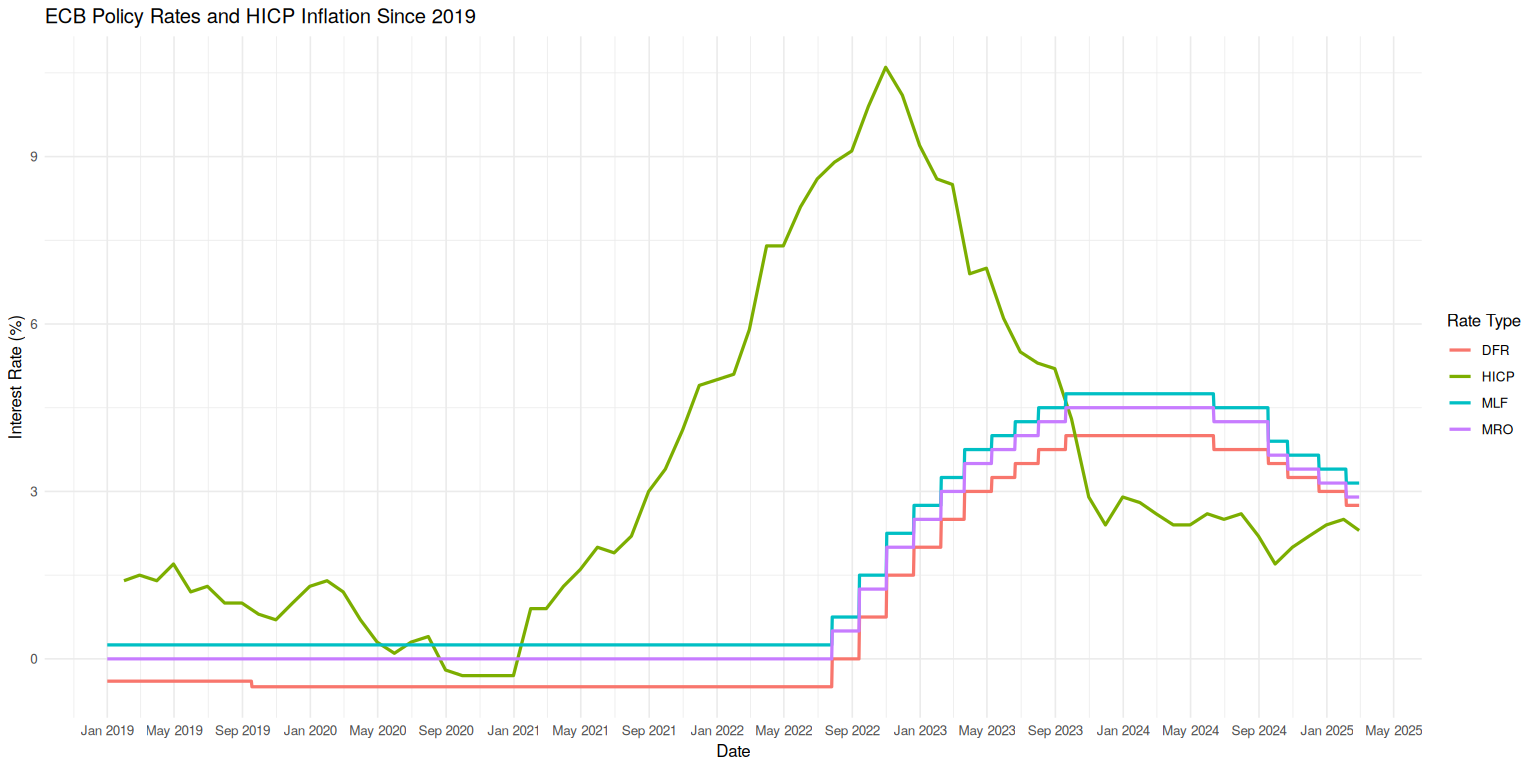

In [7]:
CHARTS$cs2_policy_rates_hicp()

### Mortgages

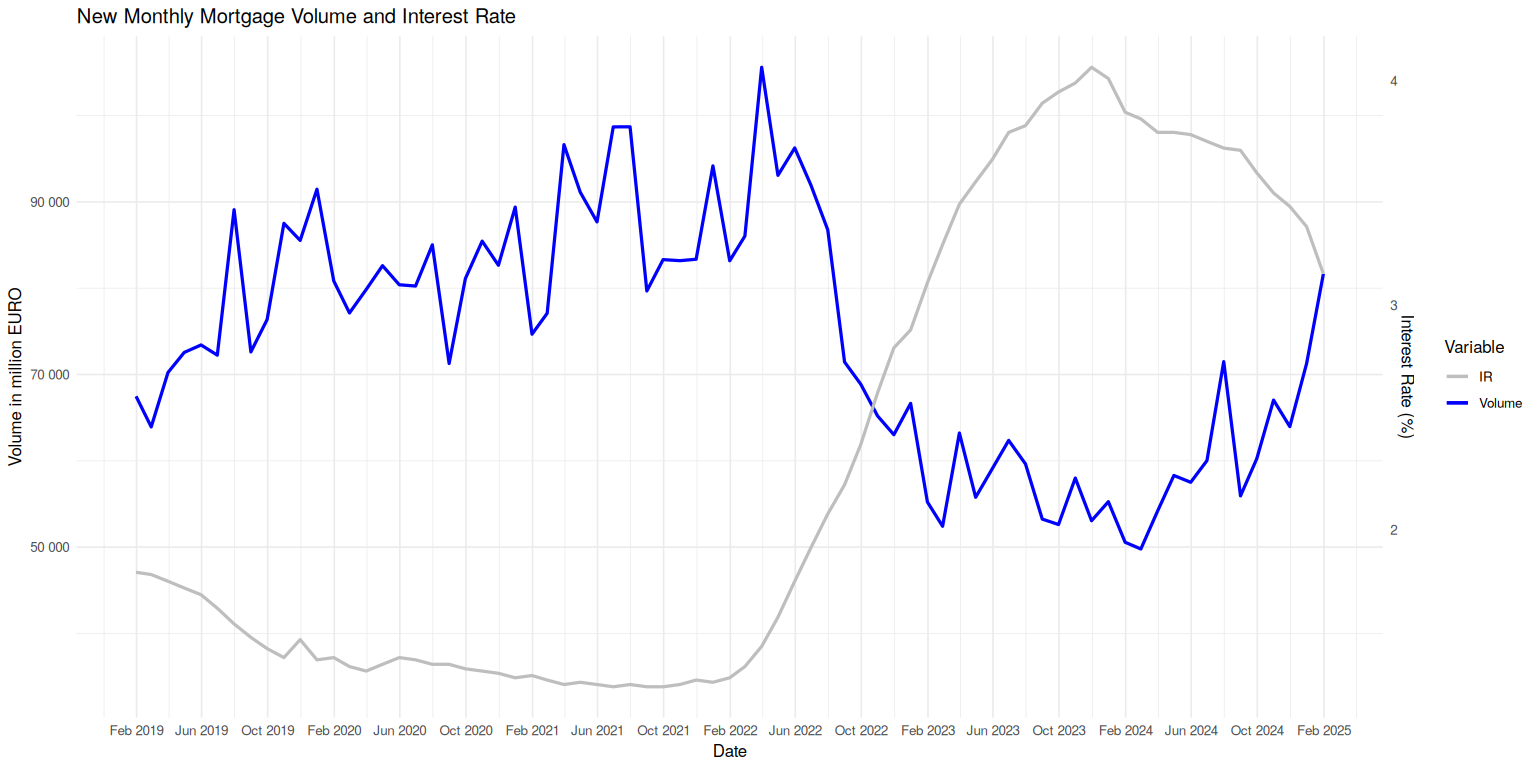

In [8]:
CHARTS$cs2_mortgage()

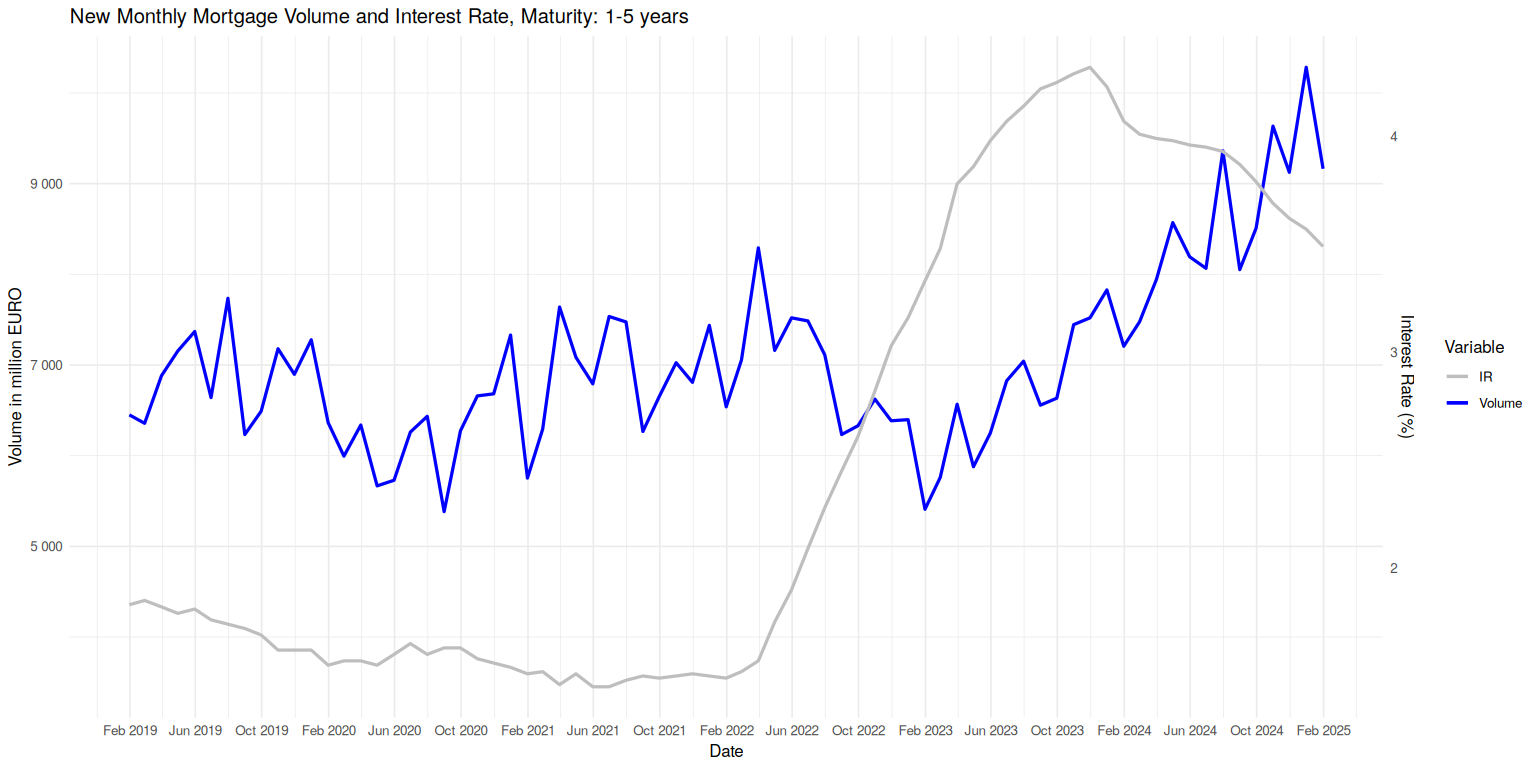

In [9]:
CHARTS$cs2_mortgage_1_5()

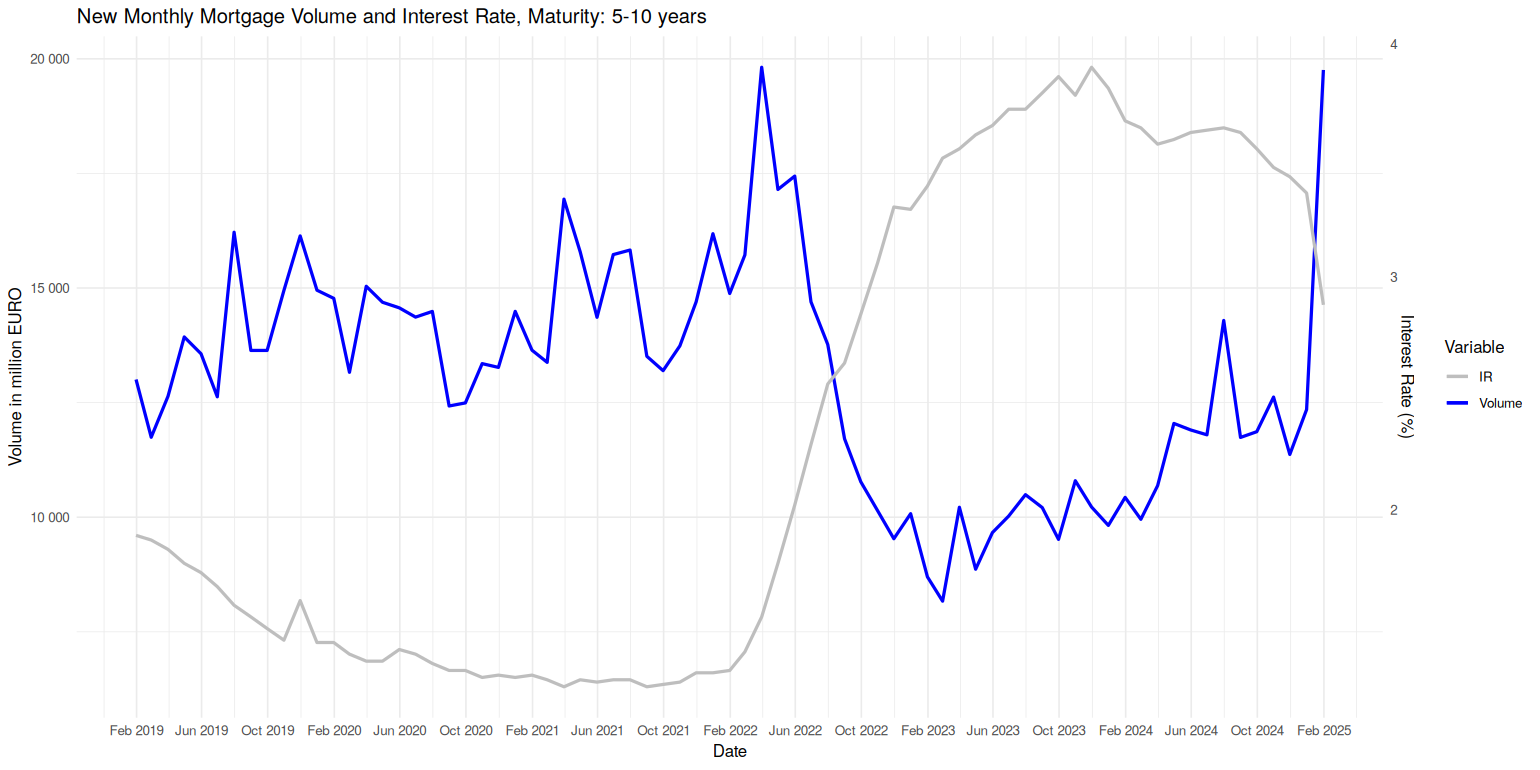

In [10]:
CHARTS$cs2_mortgage_5_10()

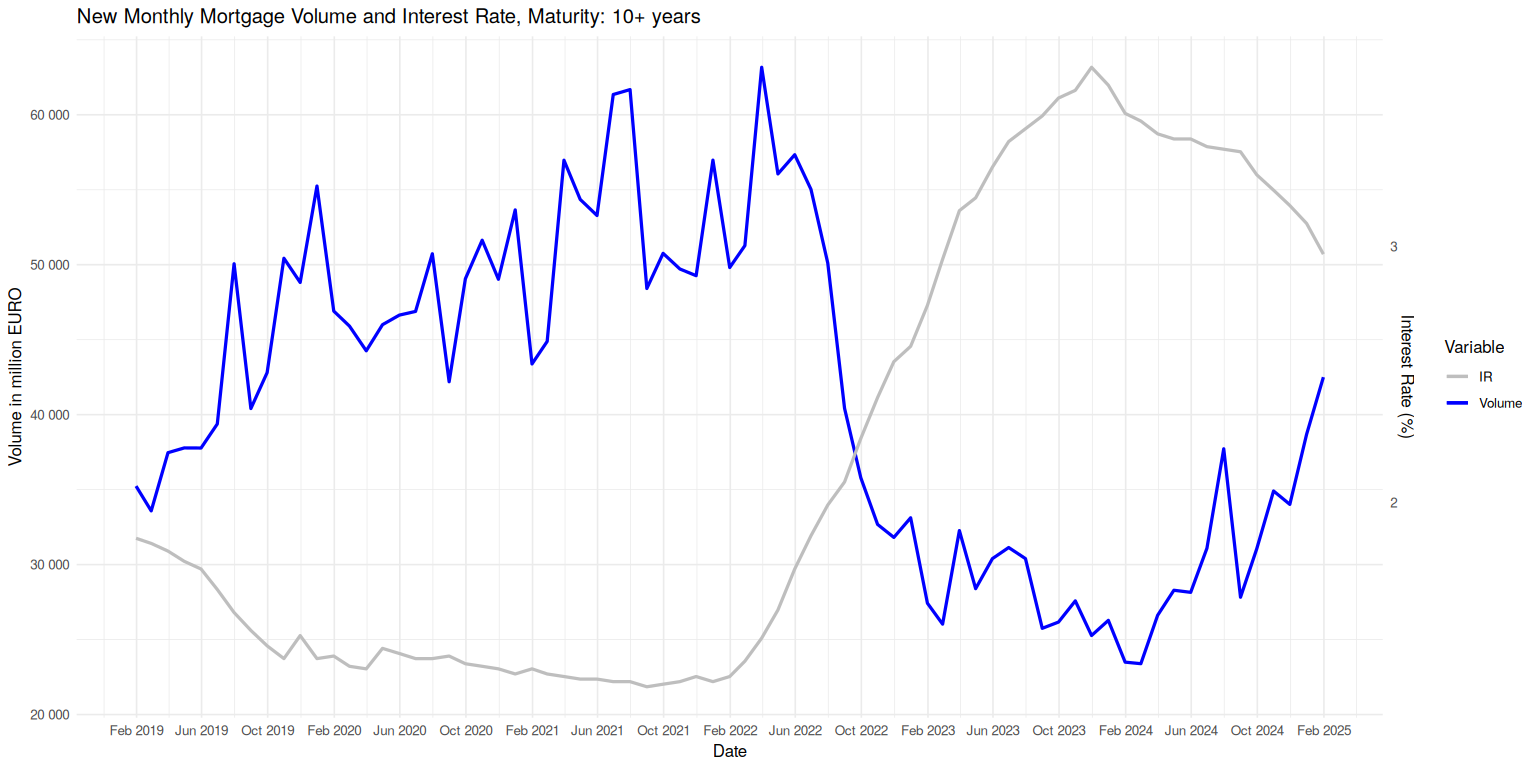

In [11]:
CHARTS$cs2_mortgage_10()

### Households

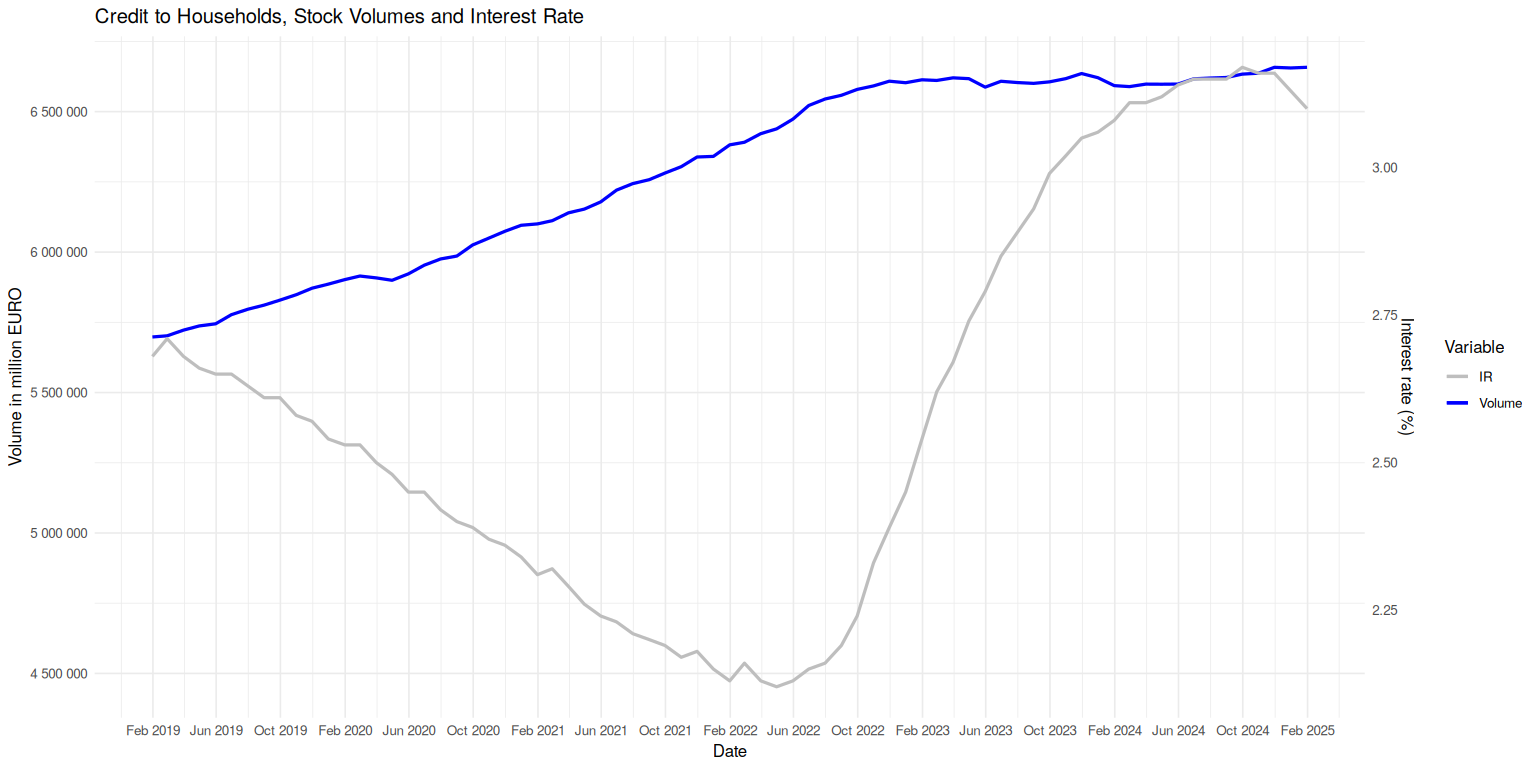

In [12]:
CHARTS$cs2_households_stock()

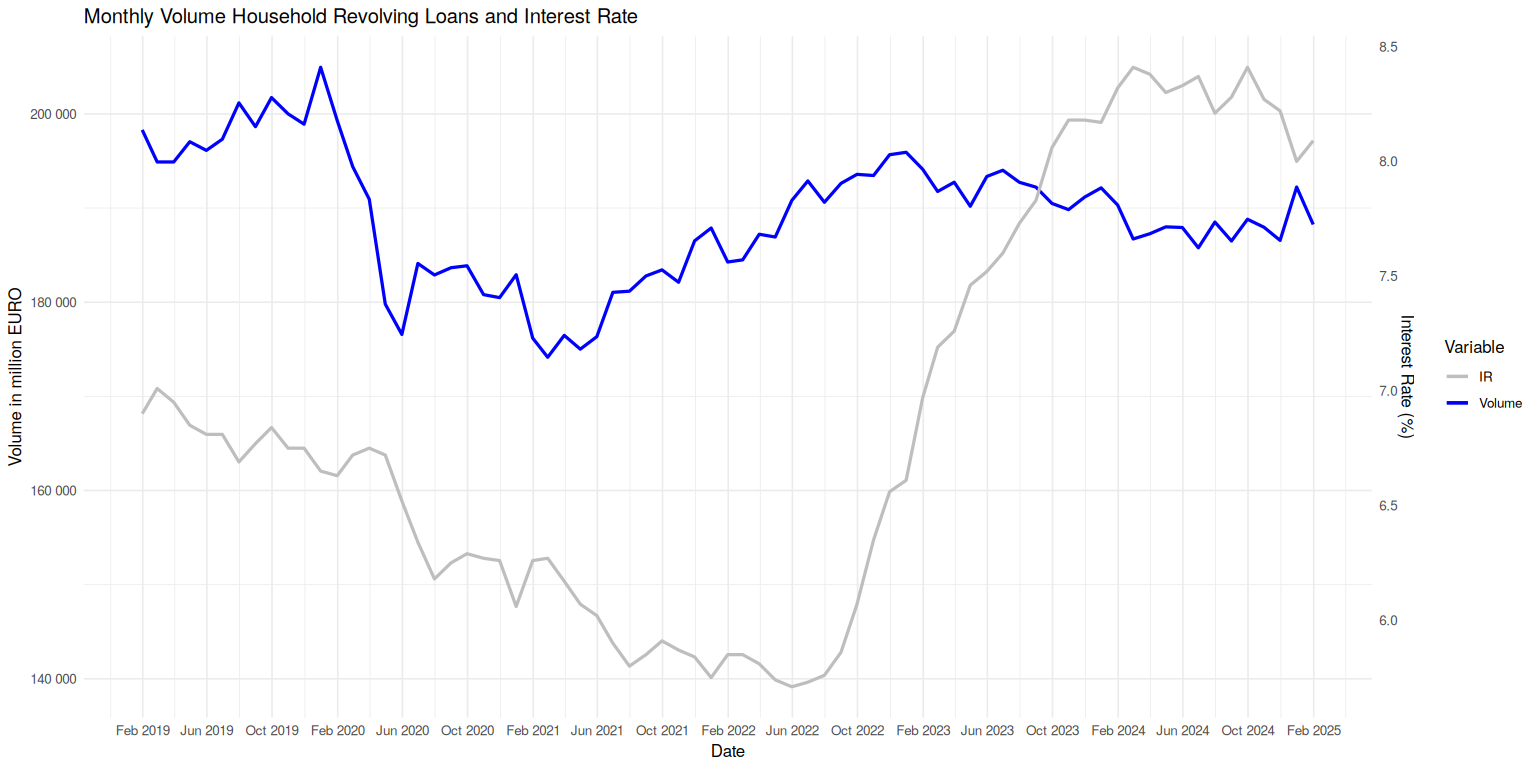

In [13]:
CHARTS$cs2_households_revolving()

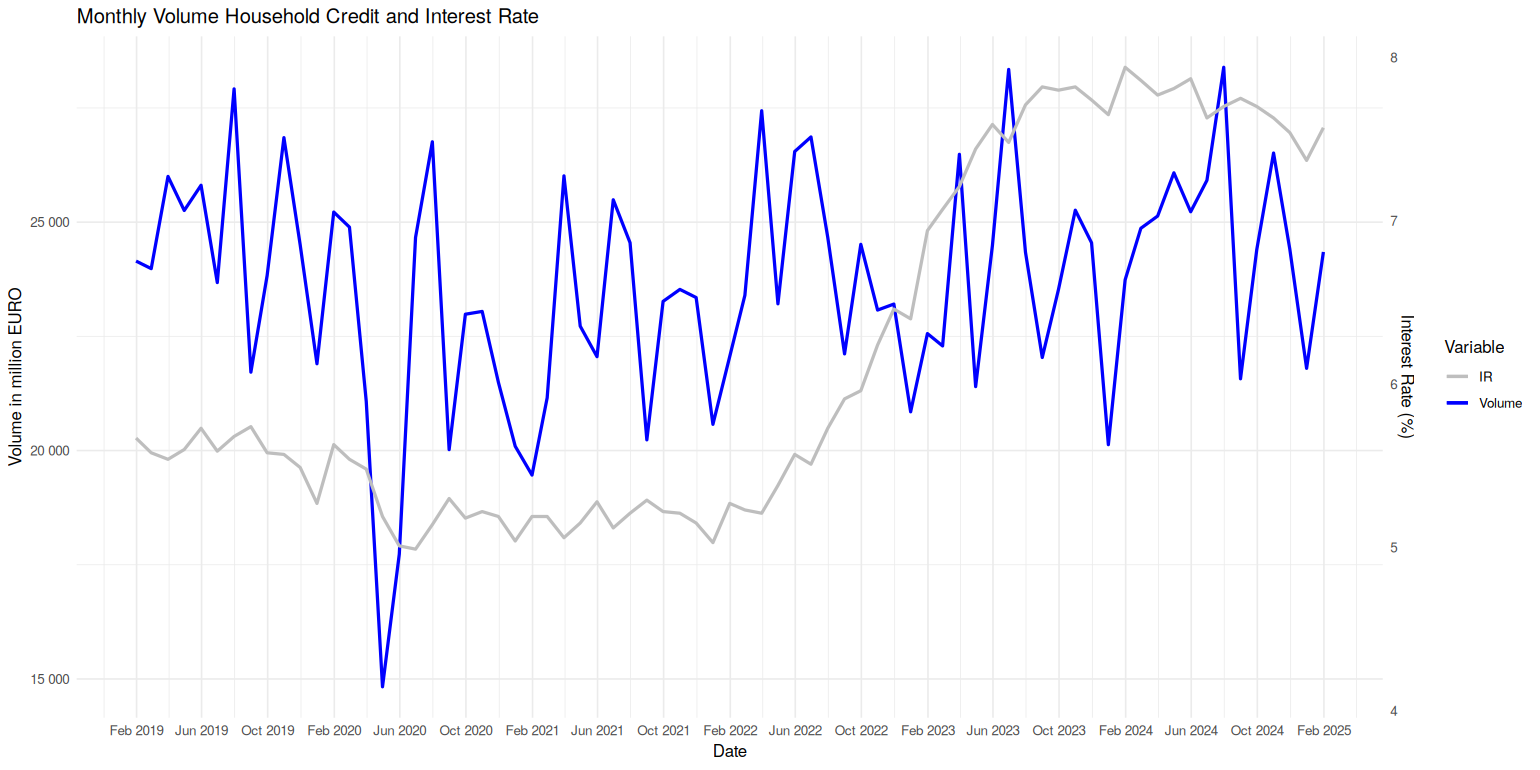

In [14]:
CHARTS$cs2_households_credit()

### Corporations

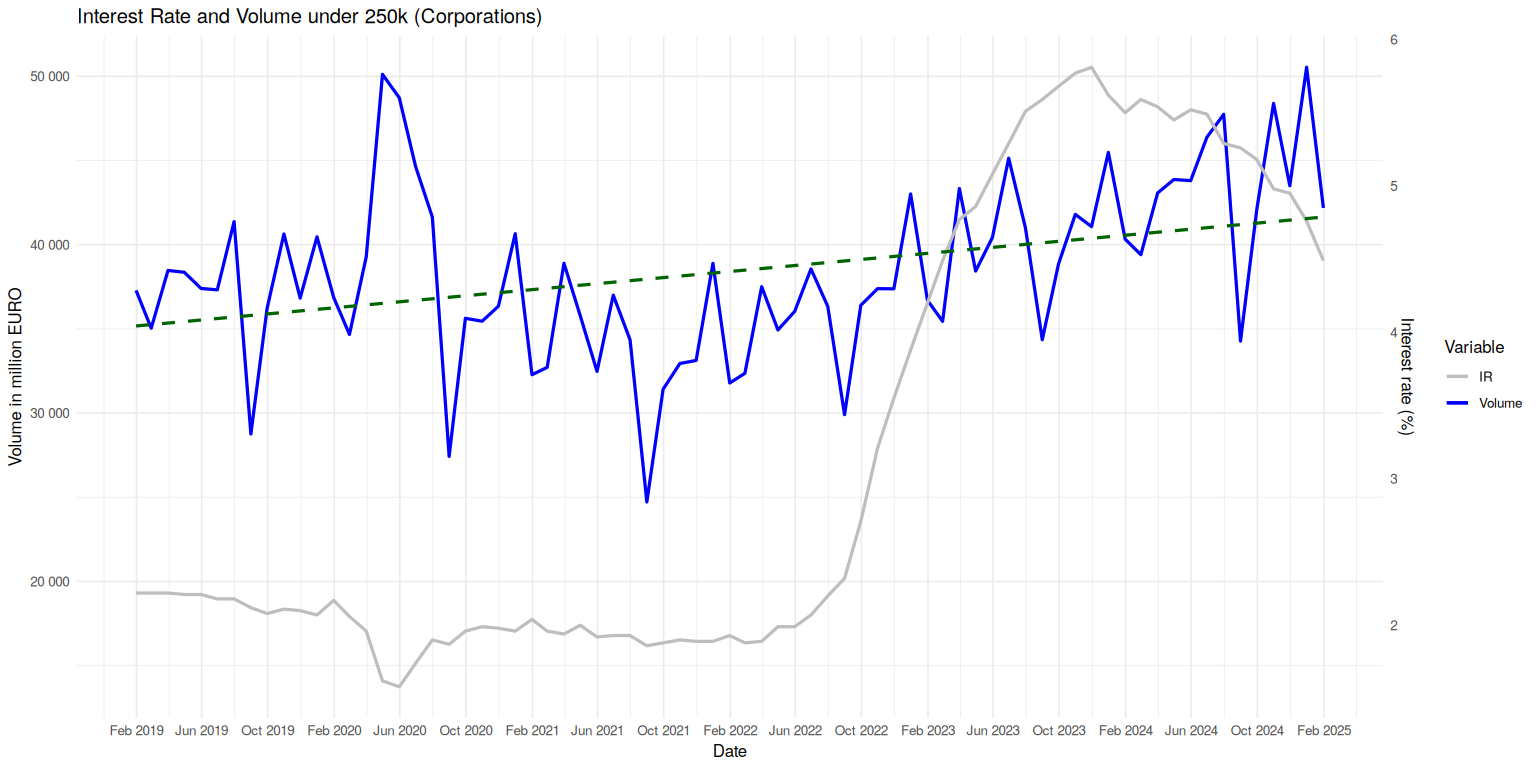

In [15]:
CHARTS$cs2_corporate_u250k()

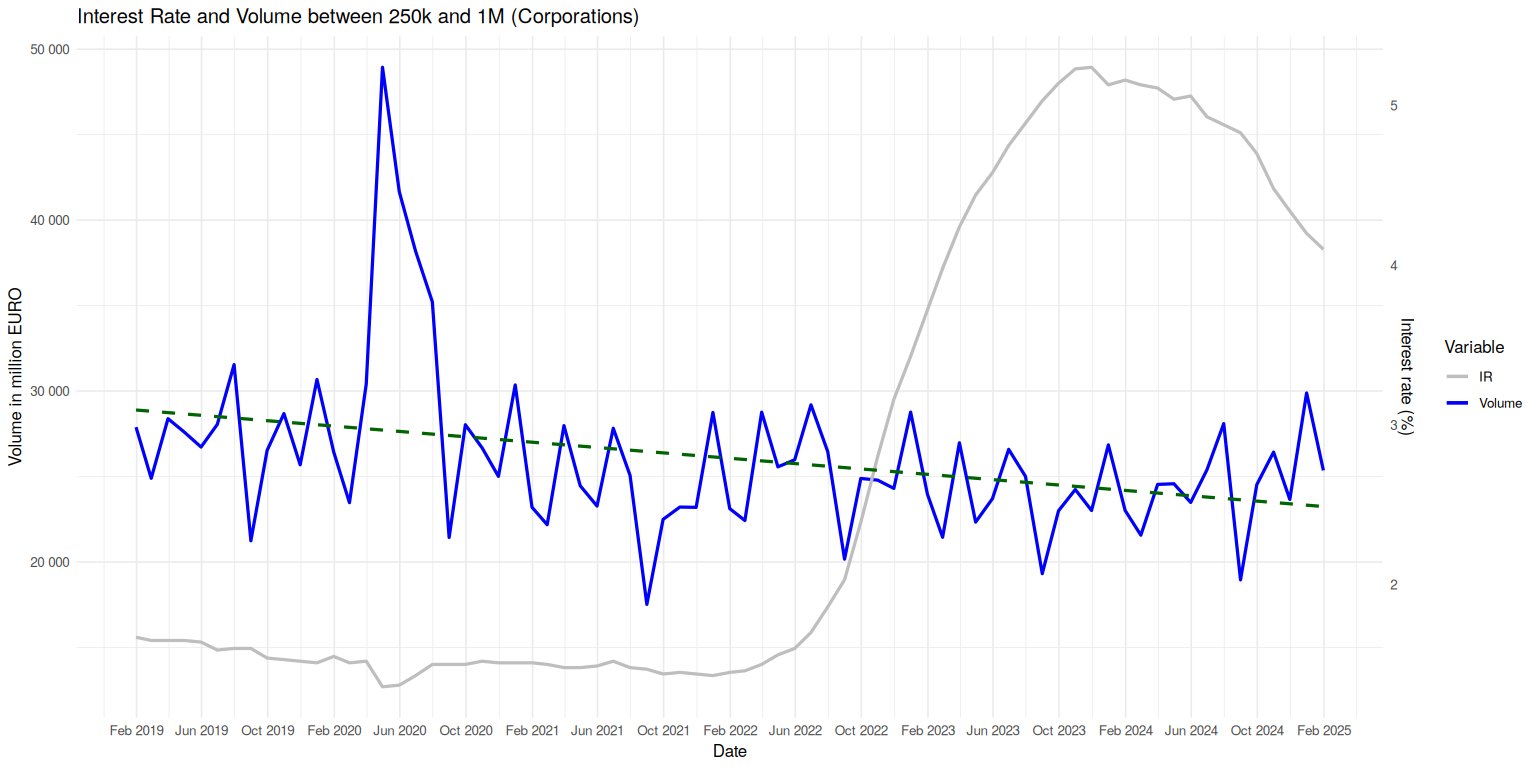

In [16]:
CHARTS$cs2_corporate_250k_1m()

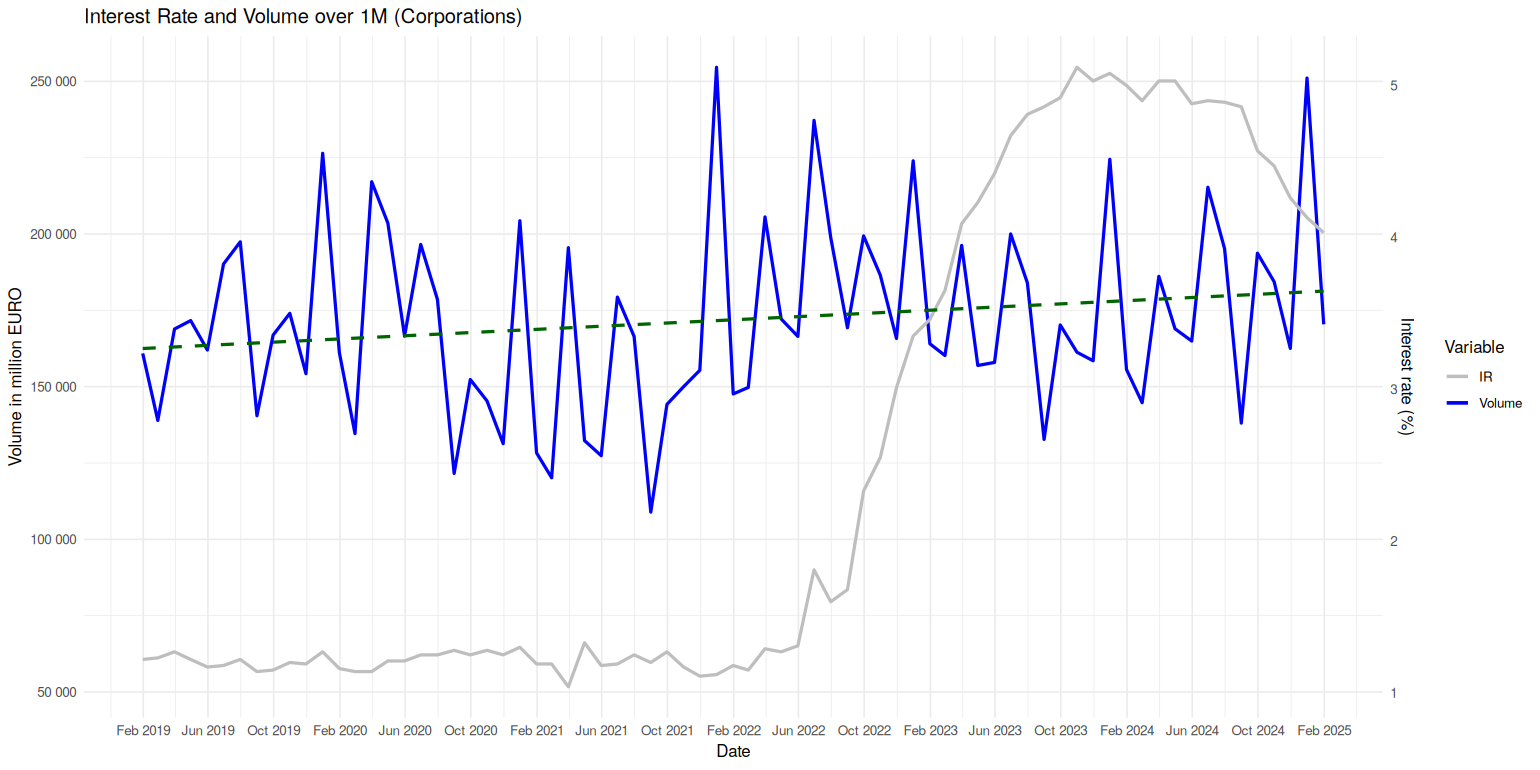

In [17]:
CHARTS$cs2_corporate_o1m()

### Pass-through by sector

Volume-weighted lending rates by sector against the MRO.

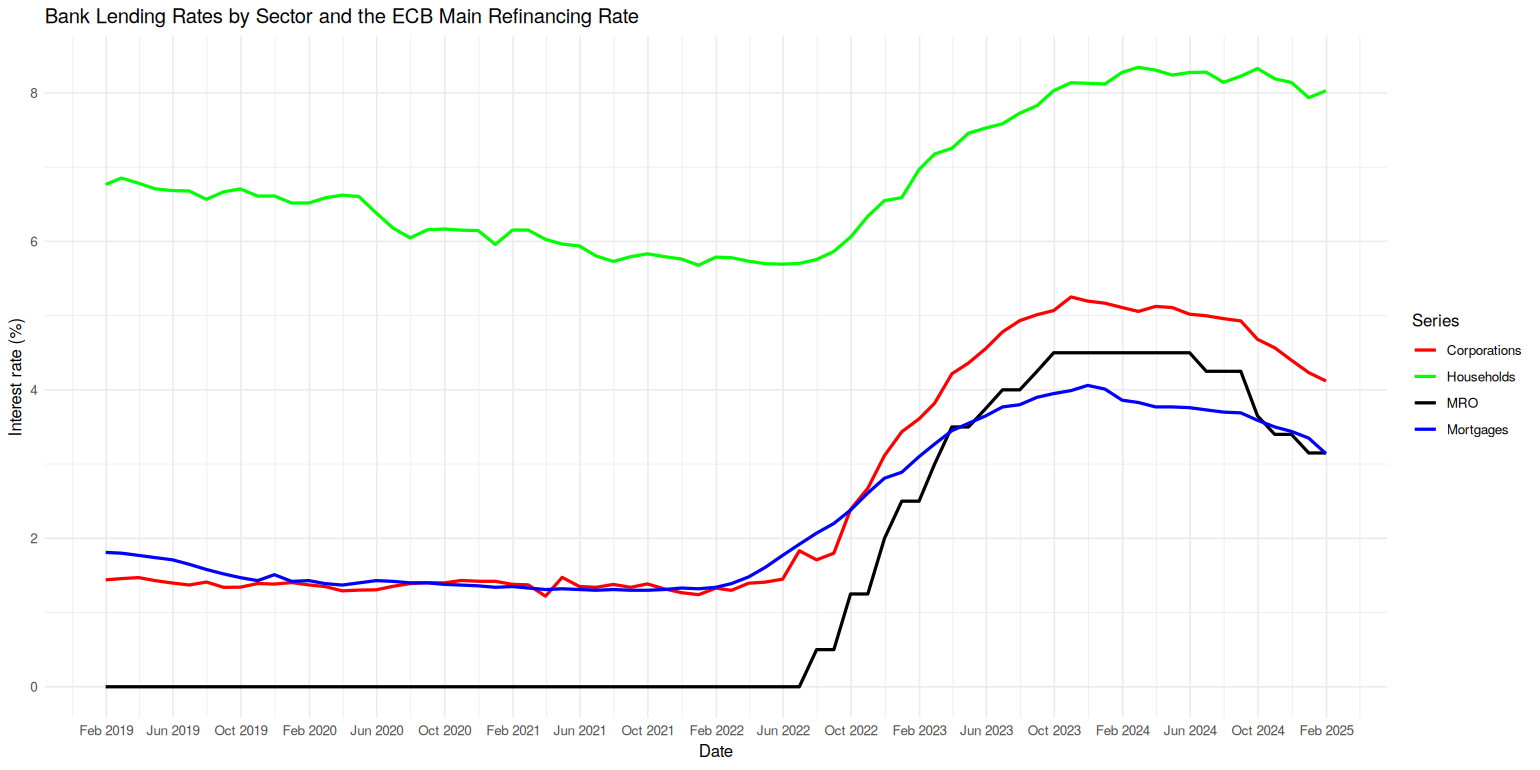

In [18]:
CHARTS$cs2_pass_through()

## 4. Saving the results

In [19]:
dir.create(OUT_DIR, showWarnings = FALSE)

# One wide monthly table with every series: MRO, HICP, and rate and volume of each product.
# Product columns are prefixed with the product key (mortgage_rate, mortgage_volume, ...)
# and all tables are joined on the month.
monthly <- reduce(c(list(mro_monthly, hicp),
                    imap(products, ~ rename_with(.x, function(n) paste0(.y, "_", n), -month))),
                  full_join, by = "month") %>%
  arrange(month)
write_csv(monthly, file.path(OUT_DIR, "cs2_monthly_data.csv"))
write_csv(sector_rates, file.path(OUT_DIR, "cs2_sector_rates.csv"))   # data of the pass-through chart
list.files(OUT_DIR)

[1] "cs2_monthly_data.csv" "cs2_sector_rates.csv"